# Conteo de estudiantes por sede, programa y semestre

Datos extraídos desde Q10 vía `extract_estudiantes.py`.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [21]:
df = pd.read_csv("../data/raw/estudiantes.csv")
print(f"Filas: {len(df):,} | Columnas: {len(df.columns)}")
df.head(3)

Filas: 1,253 | Columnas: 36


,Codigo_estudiante,Primer_nombre,Segundo_nombre,Primer_apellido,Segundo_apellido,Codigo_tipo_identificacion,Numero_identificacion,Genero,Email,Telefono,...,Nombre_programa,Consecutivo_grupo,Nombre_grupo,Consecutivo_periodo,Nombre_periodo,Codigo_nivel,Nombre_nivel,Familiares_relacionados,Sede,Nombre_programa_limpio
0,114741240555,ALFREDO,RAFAEL,SORACA,LOPEZ,2,1082916575,F,alfredosoraca.s4@gmail.com,NaN,...,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,14.0,TecLab-AuxAdmin-2025-2.1 N,5,2025-2.1,1,Semestre 01,[],TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO
1,116778110225,EMERSON,JOSE,ANAYA,MEJIA,1,1082852027,M,emersonaya2017@gmail.com,NaN,...,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,NaN,NaN,5,2025-2.1,1,Semestre 01,[],TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO
2,114654184435,YAJAIRA,YANED,NARVAEZ,SUAREZ,1,52510776,F,narvaezyajaira2@gmail.com,NaN,...,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,11.0,TecLab-MarkDig-2025-2.1,5,2025-2.1,1,Semestre 01,[],TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...


## Columnas disponibles

In [22]:
for i, c in enumerate(df.columns, 1):
    print(f"{i:2d}. {c}")

 1. Codigo_estudiante
 2. Primer_nombre
 3. Segundo_nombre
 4. Primer_apellido
 5. Segundo_apellido
 6. Codigo_tipo_identificacion
 7. Numero_identificacion
 8. Genero
 9. Email
10. Telefono
11. Celular
12. Fecha_nacimiento
13. Lugar_nacimiento
14. Lugar_residencia
15. Direccion
16. Consecutivo_sedejornada
17. Nombre_sedejornada
18. Codigo_matricula
19. Fecha_matricula
20. Fecha_renovacion
21. Condicion_matricula
22. Codigo_sede
23. Nombre_sede
24. Codigo_jornada
25. Nombre_jornada
26. Codigo_programa
27. Nombre_programa
28. Consecutivo_grupo
29. Nombre_grupo
30. Consecutivo_periodo
31. Nombre_periodo
32. Codigo_nivel
33. Nombre_nivel
34. Familiares_relacionados
35. Sede
36. Nombre_programa_limpio


---
## Conteo de estudiantes

In [23]:
# Función auxiliar para formatear los conteos
def mostrar_conteo(df, cols, titulo):
    c = df.groupby(cols).size().reset_index(name="Estudiantes")
    c = c.sort_values("Estudiantes", ascending=False).reset_index(drop=True)
    print(f"\n{'='*70}")
    print(f" {titulo}")
    print(f" Total: {c['Estudiantes'].sum():,} estudiantes")
    print(f"{'='*70}")
    display(c)
    return c

### 1. Por sede

In [24]:
por_sede = mostrar_conteo(df, ["Sede"], "ESTUDIANTES POR SEDE")


 ESTUDIANTES POR SEDE
 Total: 1,253 estudiantes


,Sede,Estudiantes
0,INEM,570
1,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,139
2,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,115
3,CIES,92
4,PESCAITO,90
5,BURITACA,86
6,BASTIDAS,71
7,MINCA,64
8,DIPLOMADO EN HERRAMIENTAS ADMINISTRATIVAS PARA...,26


### 2. Por programa

In [25]:
por_programa = mostrar_conteo(df, ["Nombre_programa_limpio"], "ESTUDIANTES POR PROGRAMA")


 ESTUDIANTES POR PROGRAMA
 Total: 1,253 estudiantes


,Nombre_programa_limpio,Estudiantes
0,TECNOLOGÍA EN MARKETING DIGITAL,266
1,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,210
2,TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y D...,176
3,TECNOLOGÍA EN GESTIÓN DE SERVICIOS GASTRONÓMICOS,153
4,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,139
5,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,115
6,TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS,76
7,CEEDS,76
8,DIPLOMADO EN HERRAMIENTAS ADMINISTRATIVAS PARA...,26
9,FICA,16


### 3. Por semestre (nivel)

In [26]:
por_semestre = mostrar_conteo(df, ["Nombre_nivel"], "ESTUDIANTES POR SEMESTRE")


 ESTUDIANTES POR SEMESTRE
 Total: 1,253 estudiantes


,Nombre_nivel,Estudiantes
0,Semestre 01,768
1,Semestre 02,461
2,Semestre 03,24


### 4. Por sede + programa

In [27]:
por_sede_programa = mostrar_conteo(df, ["Sede", "Nombre_programa_limpio"], "ESTUDIANTES POR SEDE + PROGRAMA")


 ESTUDIANTES POR SEDE + PROGRAMA
 Total: 1,253 estudiantes


,Sede,Nombre_programa_limpio,Estudiantes
0,INEM,TECNOLOGÍA EN GESTIÓN DE SERVICIOS GASTRONÓMICOS,153
1,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,139
2,INEM,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,123
3,INEM,TECNOLOGÍA EN MARKETING DIGITAL,117
4,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,115
5,INEM,TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y D...,101
6,CIES,CEEDS,76
7,INEM,TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS,76
8,PESCAITO,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,47
9,BURITACA,TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y D...,45


### 5. Por sede + programa + semestre

In [28]:
por_sede_programa_semestre = mostrar_conteo(
    df,
    ["Sede", "Nombre_programa_limpio", "Nombre_nivel"],
    "ESTUDIANTES POR SEDE + PROGRAMA + SEMESTRE"
)


 ESTUDIANTES POR SEDE + PROGRAMA + SEMESTRE
 Total: 1,253 estudiantes


,Sede,Nombre_programa_limpio,Nombre_nivel,Estudiantes
0,INEM,TECNOLOGÍA EN GESTIÓN DE SERVICIOS GASTRONÓMICOS,Semestre 01,116
1,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,TÉCNICO LABORAL EN MARKETING DIGITAL Y REDES S...,Semestre 02,115
2,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,TÉCNICO LABORAL EN AUXILIAR ADMINISTRATIVO,Semestre 02,112
3,INEM,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,Semestre 01,90
4,INEM,TECNOLOGÍA EN MARKETING DIGITAL,Semestre 01,85
5,CIES,CEEDS,Semestre 01,76
6,INEM,TECNOLOGÍA EN GESTIÓN DE PRODUCCIÓN DE MODAS,Semestre 01,76
7,INEM,TECNOLOGÍA EN GESTIÓN DEL TURISMO CULTURAL Y D...,Semestre 01,71
8,PESCAITO,TECNOLOGÍA EN GESTIÓN DE OPERACIONES LOGÍSTICAS,Semestre 01,47
9,PESCAITO,TECNOLOGÍA EN MARKETING DIGITAL,Semestre 01,43


### 6. Por período académico

In [29]:
por_periodo = mostrar_conteo(df, ["Nombre_periodo"], "ESTUDIANTES POR PERÍODO ACADÉMICO")


 ESTUDIANTES POR PERÍODO ACADÉMICO
 Total: 1,253 estudiantes


,Nombre_periodo,Estudiantes
0,2026-1,1250
1,2025-2.1,3


---
## Visualizaciones

C:\Users\Local PC\AppData\Local\Temp\ipykernel_40496\114122554.py:18: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


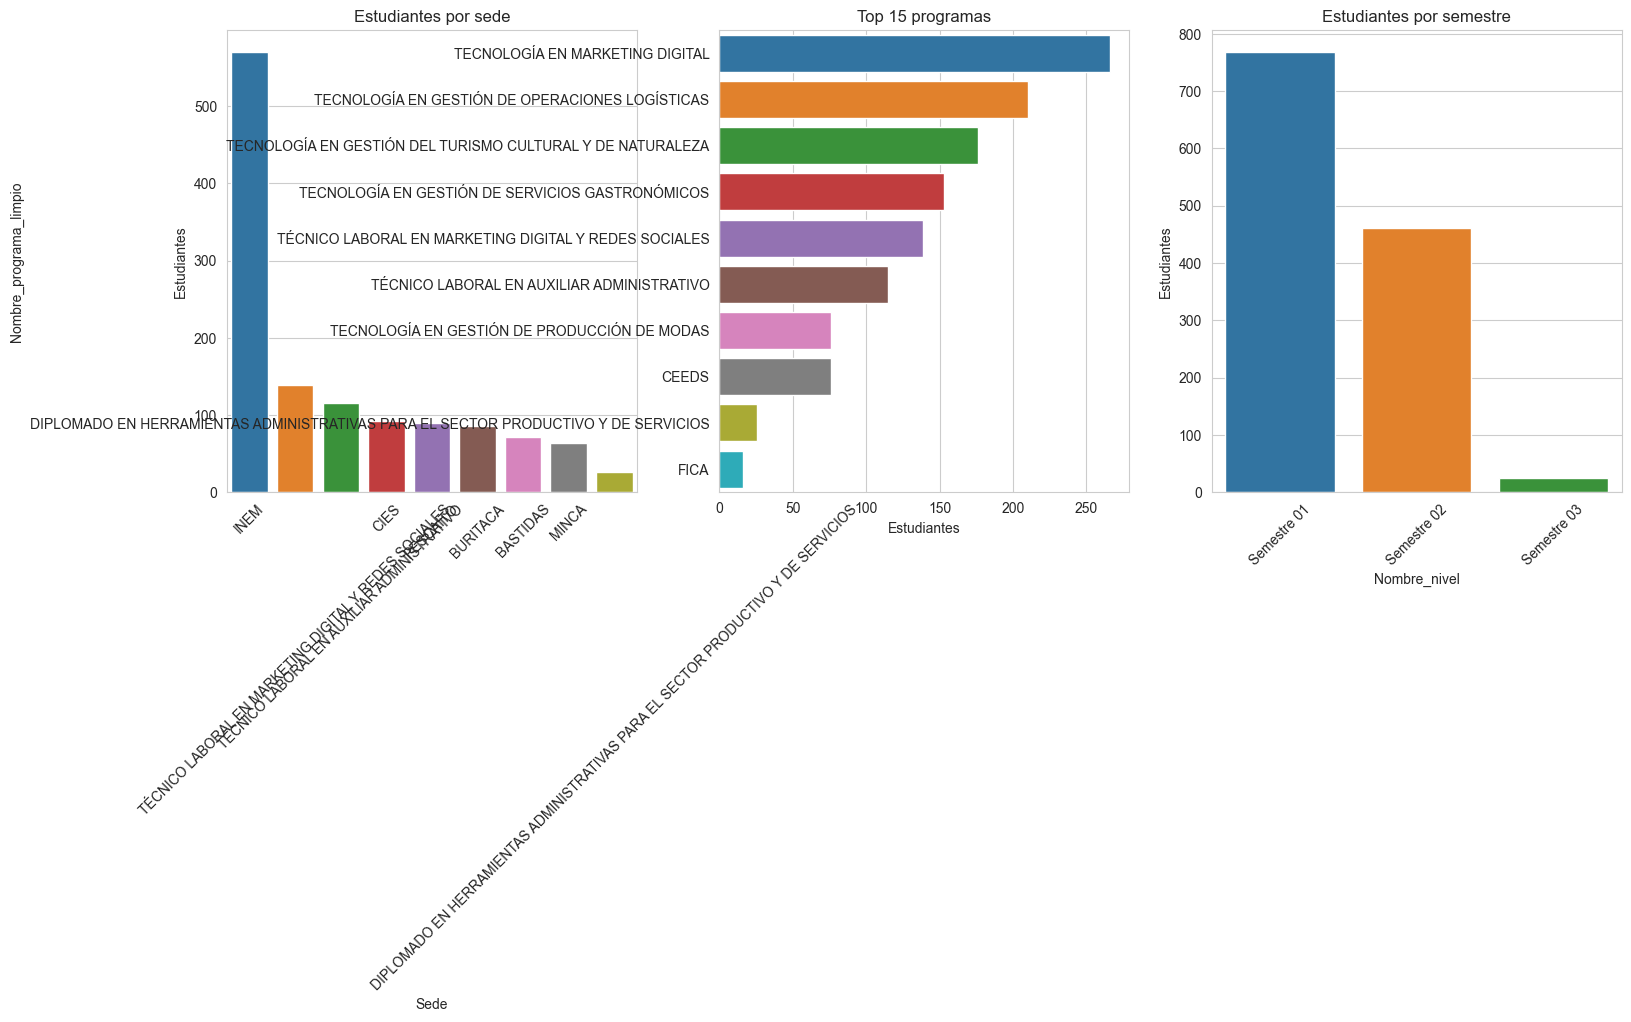

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Sede
sns.barplot(data=por_sede, x="Sede", y="Estudiantes", ax=axes[0], hue="Sede", legend=False)
axes[0].set_title("Estudiantes por sede")
axes[0].tick_params(axis="x", rotation=45)

# Programa (top 15)
top_prog = por_programa.head(15)
sns.barplot(data=top_prog, y="Nombre_programa_limpio", x="Estudiantes", ax=axes[1], hue="Nombre_programa_limpio", legend=False)
axes[1].set_title("Top 15 programas")

# Semestre
sns.barplot(data=por_semestre, x="Nombre_nivel", y="Estudiantes", ax=axes[2], hue="Nombre_nivel", legend=False)
axes[2].set_title("Estudiantes por semestre")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

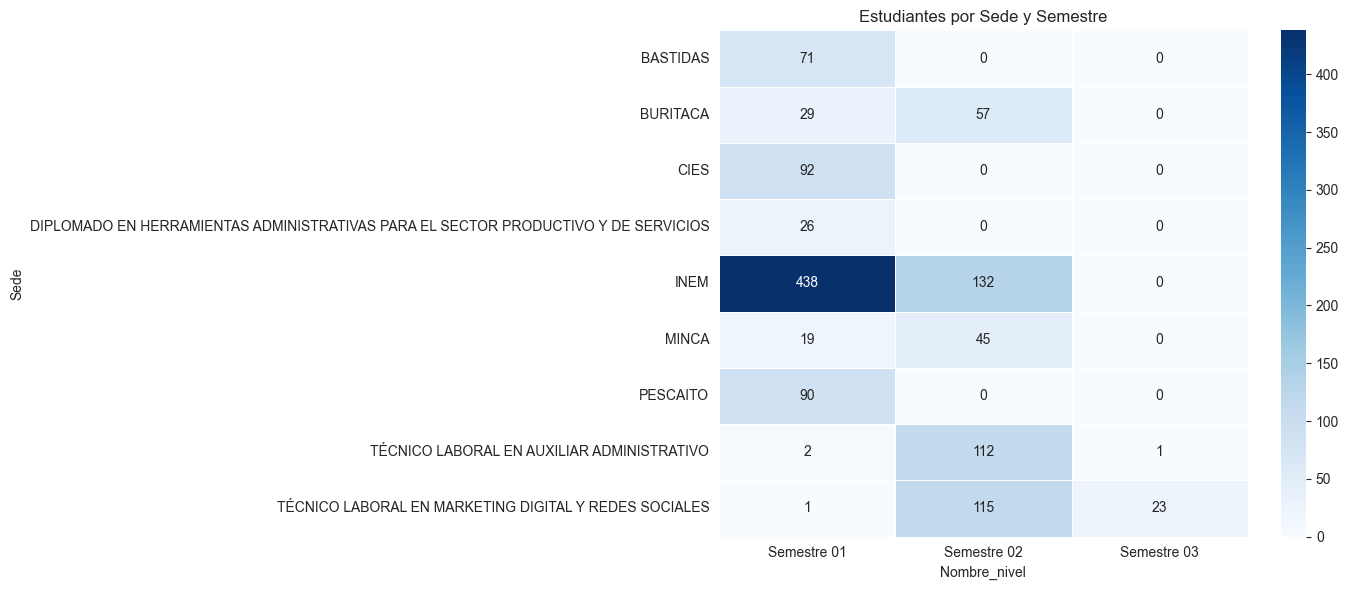

In [31]:
# Heatmap: Sede vs Semestre
pivot_sede_sem = df.groupby(["Sede", "Nombre_nivel"]).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_sede_sem, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Estudiantes por Sede y Semestre")
plt.tight_layout()
plt.show()

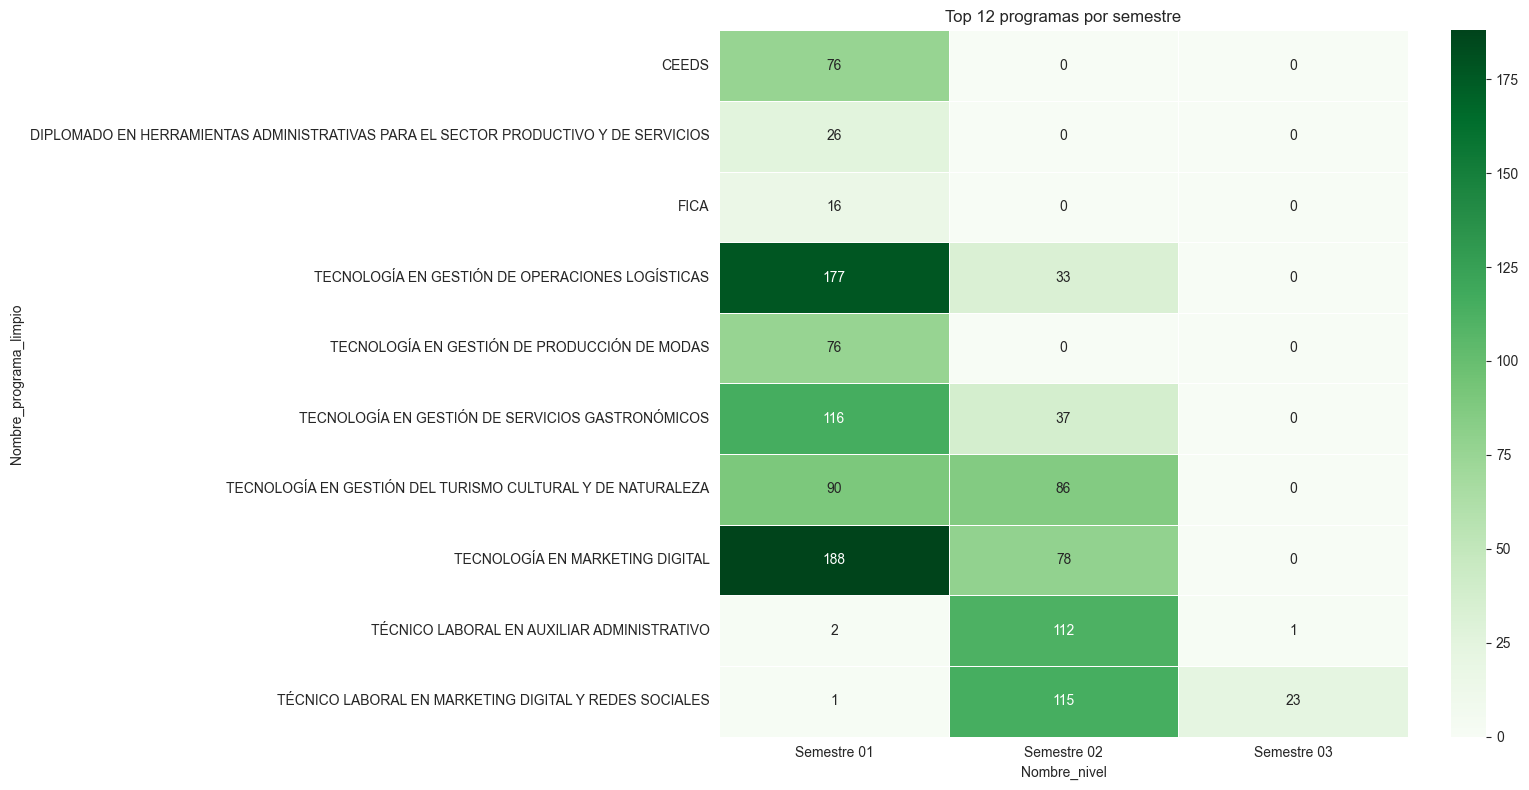

In [32]:
# Heatmap: Programa (top) vs Semestre
top_n = 12
top_programas = por_programa.head(top_n)["Nombre_programa_limpio"].tolist()
df_top = df[df["Nombre_programa_limpio"].isin(top_programas)]
pivot_prog_sem = df_top.groupby(["Nombre_programa_limpio", "Nombre_nivel"]).size().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(pivot_prog_sem, annot=True, fmt="d", cmap="Greens", linewidths=0.5)
plt.title(f"Top {top_n} programas por semestre")
plt.tight_layout()
plt.show()

In [33]:
# Resumen general
print("=== RESUMEN GENERAL ===")
print(f"Total estudiantes únicos: {df['Numero_identificacion'].nunique():,}")
print(f"Total registros (matrículas): {len(df):,}")
print(f"Sedes: {df['Sede'].nunique()}")
print(f"Programas: {df['Nombre_programa_limpio'].nunique()}")
print(f"Semestres (niveles): {df['Nombre_nivel'].nunique()}")
print(f"Períodos académicos: {df['Nombre_periodo'].nunique()}")

=== RESUMEN GENERAL ===
Total estudiantes únicos: 1,236
Total registros (matrículas): 1,253
Sedes: 9
Programas: 10
Semestres (niveles): 3
Períodos académicos: 2
